In [253]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [254]:
df=pd.read_csv('rolling_stones_spotify.csv')

In [255]:
df.shape

(1610, 18)

In [256]:
df.head()

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [257]:
df.columns

Index(['Unnamed: 0', 'name', 'album', 'release_date', 'track_number', 'id',
       'uri', 'acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity',
       'duration_ms'],
      dtype='object')

## Data Cleaning

In [258]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1610 non-null   object 
 1   album             1610 non-null   object 
 2   release_date      1610 non-null   object 
 3   track_number      1610 non-null   int64  
 4   id                1610 non-null   object 
 5   uri               1610 non-null   object 
 6   acousticness      1610 non-null   float64
 7   danceability      1610 non-null   float64
 8   energy            1610 non-null   float64
 9   instrumentalness  1610 non-null   float64
 10  liveness          1610 non-null   float64
 11  loudness          1610 non-null   float64
 12  speechiness       1610 non-null   float64
 13  tempo             1610 non-null   float64
 14  valence           1610 non-null   float64
 15  popularity        1610 non-null   int64  
 16  duration_ms       1610 non-null   int64  


No missing value available in the data

In [260]:
df.duplicated().sum()

np.int64(0)

No duplicate data availabe


In [261]:
df['release_date']=pd.to_datetime(df['release_date']) # Convert its data type
print(df['release_date'].dtypes)

datetime64[ns]


In [262]:
#Split the data into numerical and categorical
df_numeric=df.select_dtypes(include=['float64','int64'])
df_cat=df.select_dtypes(include='object')


In [263]:
print(df_numeric.shape)
print(df_cat.shape)

(1610, 12)
(1610, 4)


In [264]:
df_numeric.columns

Index(['track_number', 'acousticness', 'danceability', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'valence', 'popularity', 'duration_ms'],
      dtype='object')

## Outlier Detection

In [265]:
numeric_data=df_numeric.drop('popularity',axis=True)
numeric_data

,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms
0,1,0.0824,0.463,0.993,0.996000,0.9320,-12.913,0.1100,118.001,0.0302,48640
1,2,0.4370,0.326,0.965,0.233000,0.9610,-4.803,0.0759,131.455,0.3180,253173
2,3,0.4160,0.386,0.969,0.400000,0.9560,-4.936,0.1150,130.066,0.3130,263160
3,4,0.5670,0.369,0.985,0.000107,0.8950,-5.535,0.1930,132.994,0.1470,305880
4,5,0.4000,0.303,0.969,0.055900,0.9660,-5.098,0.0930,130.533,0.2060,305106
...,...,...,...,...,...,...,...,...,...,...,...
1605,8,0.1570,0.466,0.932,0.006170,0.3240,-9.214,0.0429,177.340,0.9670,154080
1606,9,0.0576,0.509,0.706,0.000002,0.5160,-9.427,0.0843,122.015,0.4460,245266
1607,10,0.3710,0.790,0.774,0.000000,0.0669,-7.961,0.0720,97.035,0.8350,176080
1608,11,0.2170,0.700,0.546,0.000070,0.1660,-9.567,0.0622,102.634,0.5320,121680


In [266]:
#  Using the Interquartile Range (IQR) method for outlier detection
Q1=numeric_data.quantile(0.25)
Q3=numeric_data.quantile(0.75)
IQR=Q3-Q1
print(IQR)

track_number             7.000000
acousticness             0.345400
danceability             0.215750
energy                   0.271000
instrumentalness         0.178781
liveness                 0.740750
loudness                 4.373750
speechiness              0.050100
tempo                   34.965000
valence                  0.373750
duration_ms         104706.750000
dtype: float64


In [267]:
# Define outliers as values below (Q1 - 1.5*IQR) or above (Q3 + 1.5*IQR)
outliers = ((numeric_data < (Q1 - 1.5 * IQR)) | (numeric_data > (Q3 + 1.5 * IQR))).sum()

In [268]:
# Display the count of outlier per feature
outliers

,0
track_number,77
acousticness,4
danceability,0
energy,8
instrumentalness,272
liveness,0
loudness,14
speechiness,92
tempo,34
valence,0


## Conclusion:
No need to remove ouliers for feature like **track_number** beacuse this not a continuous feature, so outliers don’t distort analysis.

Apply **Winsorization Technique** for acousticness, energy, loudness, tempo, duration_ms, as they have less outlier count

**Extreme Outlier counts** - For Highly skewed features like instrumentalness and speechiness (some songs have almost 0 speechiness while others are fully spoken).

No need to handle these outliers (instrumentalness and speechiness) as some songs are fully spoken and some might be fully composed with instrumentals. So all the songs carry meaningful information in the data.


## Outlier Handling

In [269]:
df1=df[['acousticness','energy','loudness','tempo', 'duration_ms']]
df1


,acousticness,energy,loudness,tempo,duration_ms
0,0.0824,0.993,-12.913,118.001,48640
1,0.4370,0.965,-4.803,131.455,253173
2,0.4160,0.969,-4.936,130.066,263160
3,0.5670,0.985,-5.535,132.994,305880
4,0.4000,0.969,-5.098,130.533,305106
...,...,...,...,...,...
1605,0.1570,0.932,-9.214,177.340,154080
1606,0.0576,0.706,-9.427,122.015,245266
1607,0.3710,0.774,-7.961,97.035,176080
1608,0.2170,0.546,-9.567,102.634,121680


In [270]:
import warnings
warnings.filterwarnings('ignore')

In [271]:
from scipy.stats.mstats import winsorize

# Apply Winsorization (capping extreme values)
for col in df1.columns:
  df1[col]=winsorize(df1[col],limits=[0.05,0.05]) # Capping 5% lowest & highest values , replace lowest 5% of values with 5th percentile and highest 5% of values with 95th percentile


In [272]:
#  Detect outliers after winsorization technique
Q1=df1.quantile(0.25)
Q3=df1.quantile(0.75)
IQR=Q3-Q1


# Define outliers
outliers = ((df1 < (Q1 - 1.5 * IQR)) | (df1 > (Q3 + 1.5 * IQR))).sum()


In [273]:
outliers

,0
acousticness,0
energy,0
loudness,0
tempo,0
duration_ms,0


**Conclusion** :  All the mild number of outliers has been removed by Capping Method and the feature with extreme counts of outliers carry infomative insights.

In [274]:
df.update(df1)
df.shape

(1610, 17)

##  Exploratory Data Analysis (EDA)

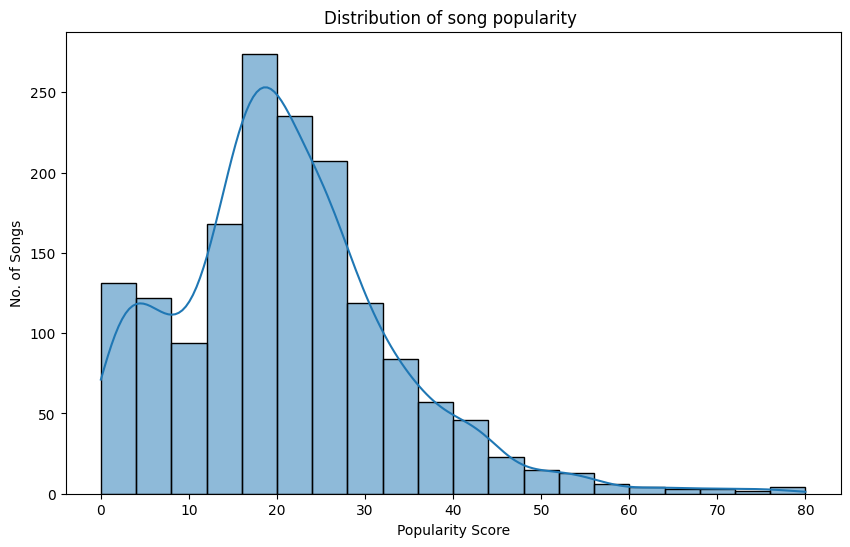

In [275]:
# Visualizing song popularity distribution.
plt.figure(figsize=(10,6))
sns.histplot(df['popularity'],bins=20,kde=True)
plt.xlabel('Popularity Score')
plt.ylabel('No. of Songs')
plt.title('Distribution of song popularity ')
plt.show()

Song Popularity Distribution:

The majority of the songs have relatively low popularity scores.

Only a few songs have high popularity scores.

 Identifying the top two albums with the most popular songs.


In [276]:
# Display the top two albums with the most popular songs (popularity > 50 as a threshold)
df[df['popularity']>50].groupby('album').size().sort_values(ascending=False).head(2)

,0
album,
Sticky Fingers (Remastered),6
Exile On Main Street (2010 Re-Mastered),4


Top Two Albums with the Most Popular Songs:

"Sticky Fingers (Remastered)" has the highest number of popular songs (6).

"Exile On Main Street (2010 Re-Mastered)" follows with 4 popular songs.

## Exploring correlations between popularity and other features.

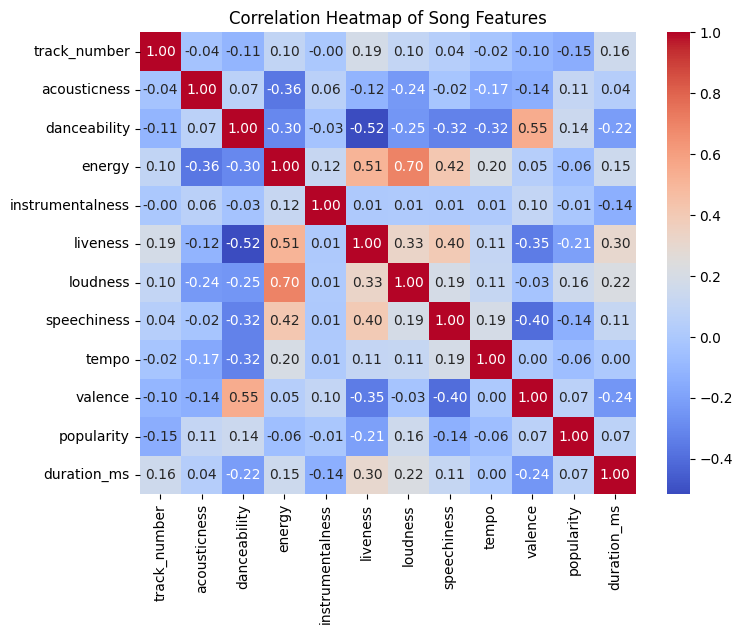

In [277]:
plt.figure(figsize=(8,6))
sns.heatmap(df_numeric.corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title("Correlation Heatmap of Song Features")
plt.show()

**Positive Correlations**

Energy & Loudness (~0.70) :  Loud songs tend to be high-energy.

Danceability & Valence (~0.55) : Happier songs are moderately danceable not strongly.



**Negative Correlations**


Danceability & Liveness (~ -0.52) : Live recordings are less structured for dancing.

Acousticness & Energy (~ -0.36) :  Acoustic tracks are generally lower in energy.

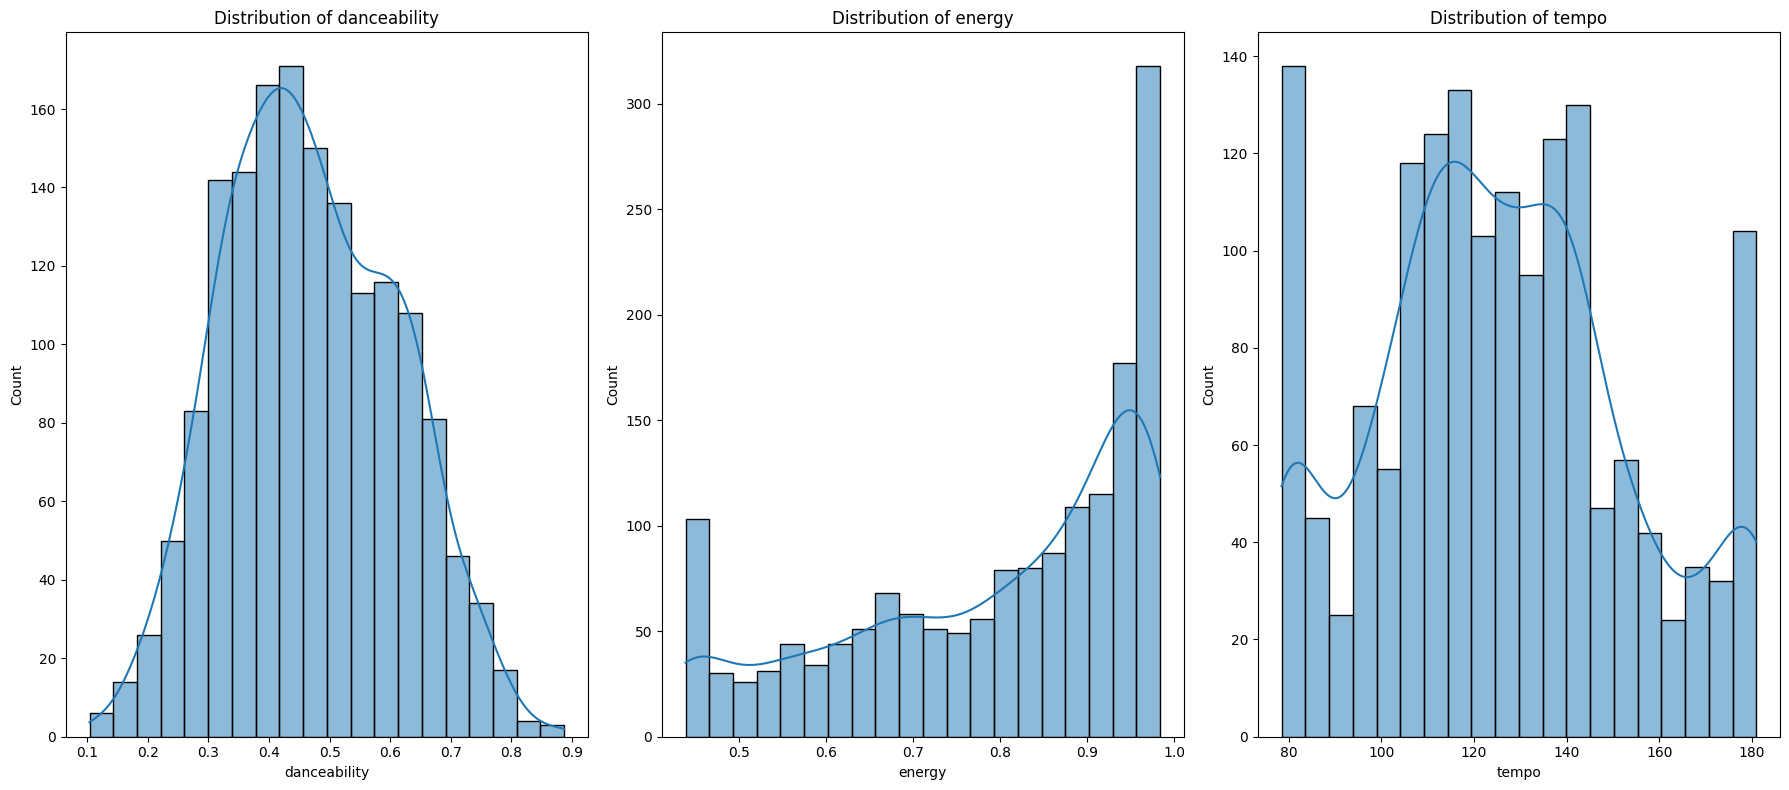

In [278]:
#  Distribution of Danceability, energy and tempo


features=['danceability','energy','tempo']
# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 8))  # 1 row, 3 columns


for i , param in enumerate(features):

   sns.histplot(df[param], bins=20, kde=True, ax=axes[i])  # Use ax=axes[i] to plot in the correct subplot
   axes[i].set_title(f'Distribution of {param}')

plt.tight_layout()
plt.show()



Insights from the Exploratory Data Analysis (EDA)

1️ Distribution of Danceability

Observation: The danceability scores are moderately skewed with most values centered around 0.3 to 0.76

Insight: Most Rolling Stones songs are somewhat danceable, but they are not highly optimized for dancing (compared to EDM or pop music).

2 Distribution of Energy

Observation: The energy distribution is left-skewed, meaning most songs have moderate to high energy.

Insight: The Rolling Stones’ music is generally energetic, which aligns with their rock-and-roll genre.

3️ Distribution of Tempo

Observation: The tempo distribution appears bimodal, with peaks around 90 BPM and 140 BPM.

Insight: Rolling Stones songs likely fall into two tempo categories—some are mid-tempo rock songs, while others are fast-paced, high-energy tracks.


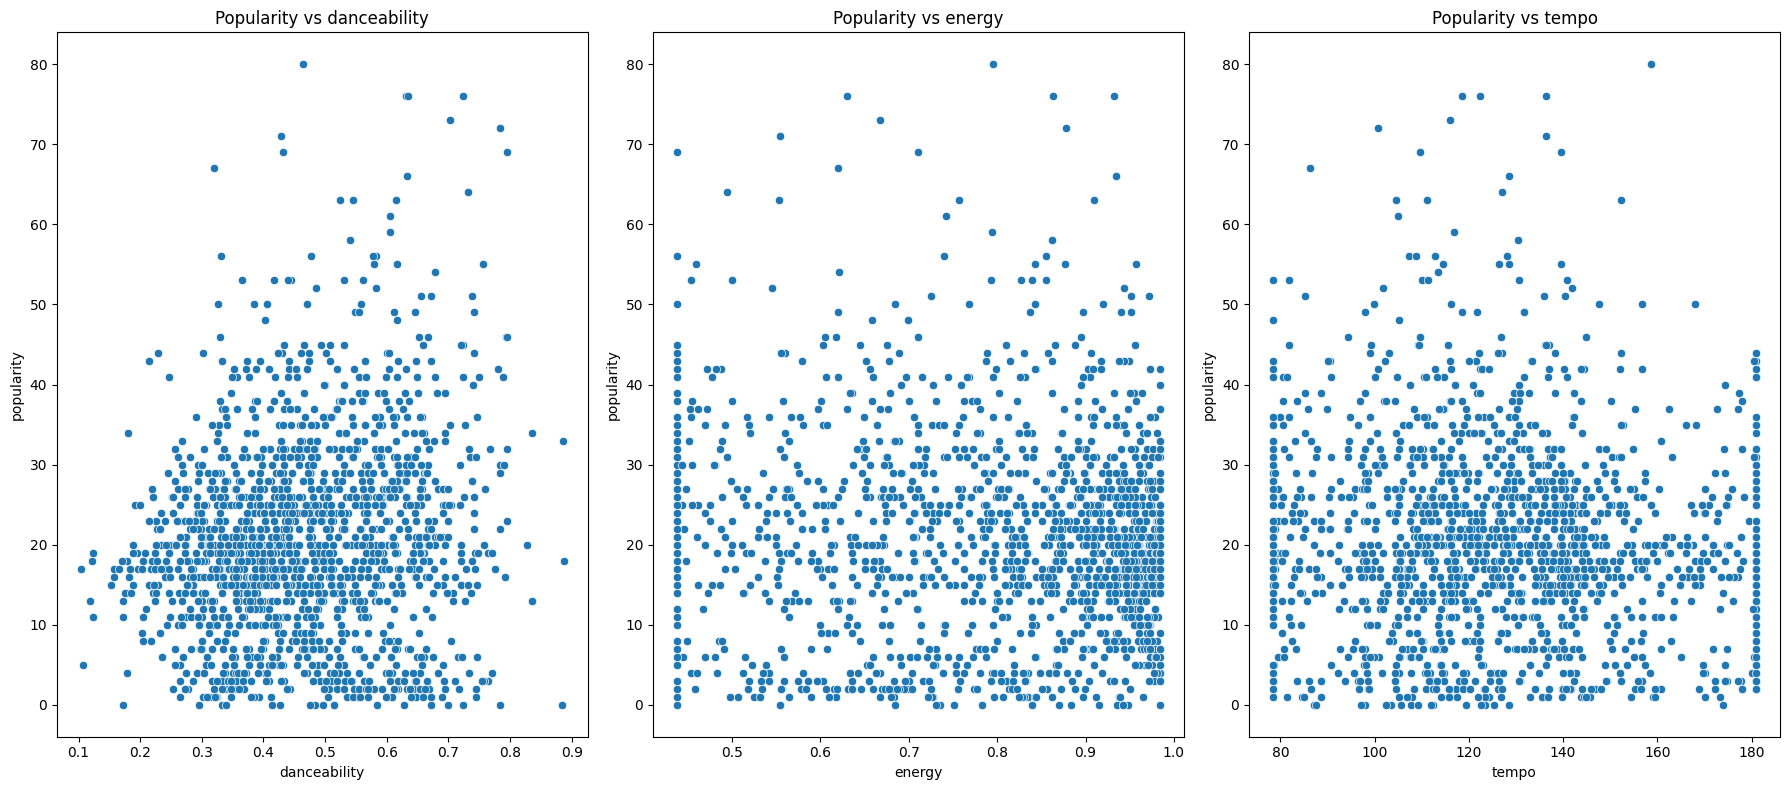

In [279]:
#  Scatter plot


features=['danceability','energy','tempo']
# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 8))  # 1 row, 3 columns


for i , param in enumerate(features):

   sns.scatterplot(x=df[param],y=df['popularity'] , ax=axes[i])  # Use ax=axes[i] to plot in the correct subplot
   axes[i].set_title(f'Popularity vs {param}')

plt.tight_layout()
plt.show()


Key Takeaways:

Weak or No Correlation:
There doesn’t seem to be a strong correlation between popularity and danceability, energy, or tempo. The data points are widely spread.

 Most Songs Have Low Popularity:
A large concentration of songs falls in the 0-30 popularity range across all three graphs. This suggests that only a few songs become highly popular.

No Strong Trends in Popularity:
Unlike strong correlations where data follows a clear upward/downward trend, these plots show scattered points, meaning other factors might influence popularity more.

### Feature Engineering

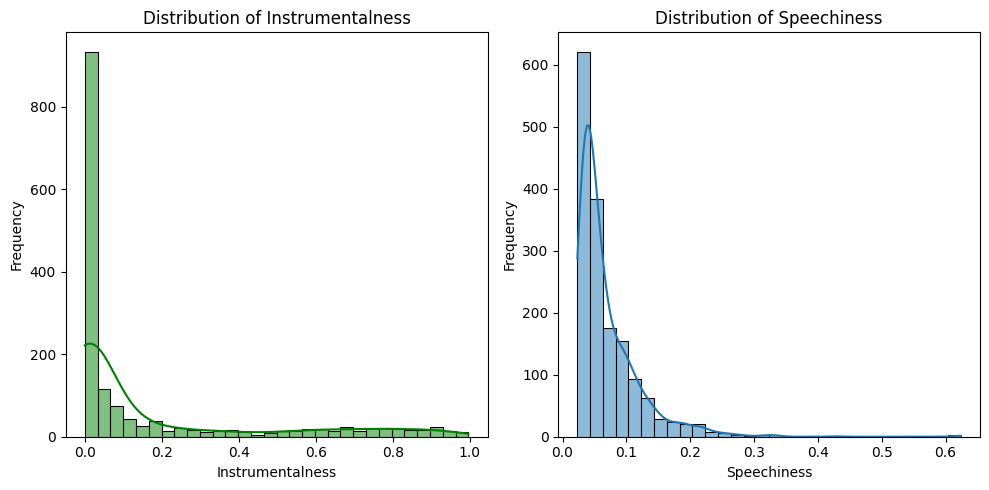

In [280]:
# Visualize distribution of  instrumentalness and speechiness
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df['instrumentalness'],kde=True,color='green',bins=30)
plt.xlabel("Instrumentalness")
plt.ylabel("Frequency")
plt.title("Distribution of Instrumentalness")

plt.subplot(1,2,2)
sns.histplot(df['speechiness'],kde=True,bins=30)
plt.xlabel("Speechiness")
plt.ylabel("Frequency")
plt.title("Distribution of Speechiness")

# Display the plots
plt.tight_layout()
plt.show()

In [281]:
# # Log Transformation (Instrumentalness & Speechiness )

# # # Apply Log Transformation to Highly Skewed Features
# df["instrumentalness"] = np.log1p(df["instrumentalness"])  # log(1 + x) to avoid log(0)
# df["speechiness"] = np.log1p(df["speechiness"])

In [282]:
# Standardizing the numerical features
from sklearn.preprocessing import StandardScaler

In [283]:
scaler = StandardScaler()
new_scaled_data = scaler.fit_transform(df[numeric_data.columns])


In [284]:
new_scaled_data

array([[-1.16094134, -0.7557131 , -0.0413433 , ..., -0.2816496 ,
        -2.38759041, -1.49439304],
       [-1.00846006,  0.8816831 , -1.00796305, ...,  0.2091123 ,
        -1.14267825,  0.01315549],
       [-0.85597878,  0.78471378, -0.58462593, ...,  0.15844571,
        -1.16430633,  0.1333075 ],
       ...,
       [ 0.2113902 ,  0.57692239,  2.265844  , ..., -1.04642691,
         1.093665  , -0.91433809],
       [ 0.36387148, -0.13418595,  1.63083832, ..., -0.84219205,
        -0.21699652, -1.49439304],
       [ 0.51635276,  0.63233343,  1.82134003, ..., -0.01631572,
         1.67329748, -0.7566619 ]])

### Dimensionality Reduction

In [285]:
from sklearn.decomposition import PCA

In [286]:
#Apply pca on standardized numerical features

pca=PCA(n_components=None)
pca_transformed=pca.fit_transform(new_scaled_data)

In [287]:
# Explained variance ratio (how much variance is retained)
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.28546379, 0.14826672, 0.10809222, 0.09529397, 0.08359483,
       0.07392267, 0.06470765, 0.05142103, 0.04780364, 0.02613552,
       0.01529795])

In [288]:
explained_variance.cumsum()

array([0.28546379, 0.4337305 , 0.54182273, 0.6371167 , 0.72071153,
       0.7946342 , 0.85934185, 0.91076289, 0.95856652, 0.98470205,
       1.        ])

In [289]:
pca.get_feature_names_out()

array(['pca0', 'pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6', 'pca7',
       'pca8', 'pca9', 'pca10'], dtype=object)

Cumulative Explained Variance Analysis:

2 components explain ~43.3% of the variance .
8 components explain ~91.1% of the variance.
9 components explain ~95.9% of the variance (common threshold).

In [290]:
# Apply PCA with 9 components (to retain ~95% variance)
pca_optimal = PCA(n_components=9)
pca_transformed_optimal = pca_optimal.fit_transform(new_scaled_data)
pca_transformed_optimal

array([[ 0.81527998, -0.12023428,  2.84455106, ..., -1.69396262,
         1.20827   ,  0.20693512],
       [ 1.84002952, -0.5085907 ,  0.74609256, ..., -0.44662105,
        -0.76026991,  0.71072109],
       [ 1.98455812, -0.39020606,  0.88612061, ..., -0.05712845,
        -0.18328692,  0.3304694 ],
       ...,
       [-2.42039796,  0.62682971, -0.91924637, ...,  1.46054129,
        -0.17437044, -0.13725994],
       [-2.51121644, -0.43631295, -0.02280766, ...,  0.34870868,
        -0.29494492, -0.29824376],
       [-1.99572575,  1.39457312, -0.78727431, ...,  1.54286254,
        -0.12951128,  0.33959573]])

### Cluster Analysis

In [291]:
from sklearn.cluster import KMeans

In [292]:
# Use the Elbow Method to find the optimal number of clusters
wcss = []
cluster_range = range(1, 21)  # Testing k from 1 to 20

In [293]:
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_transformed_optimal)
    wcss.append(kmeans.inertia_)  # Sum of squared distances


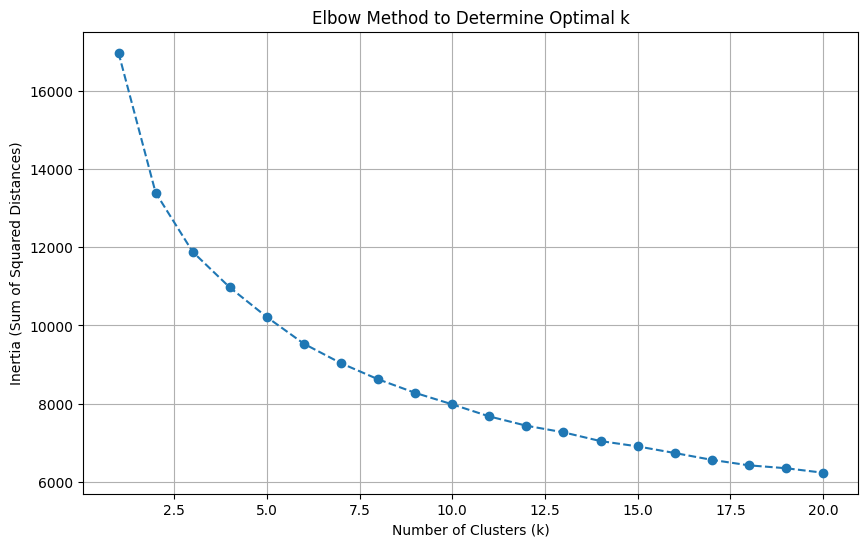

In [294]:
# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, wcss, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.title("Elbow Method to Determine Optimal k")
plt.grid()
plt.show()

Elbow Point: 2

In [295]:
# Apply K-Means Clustering with k=2
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
df["cluster"] = kmeans_final.fit_predict(pca_transformed_optimal)

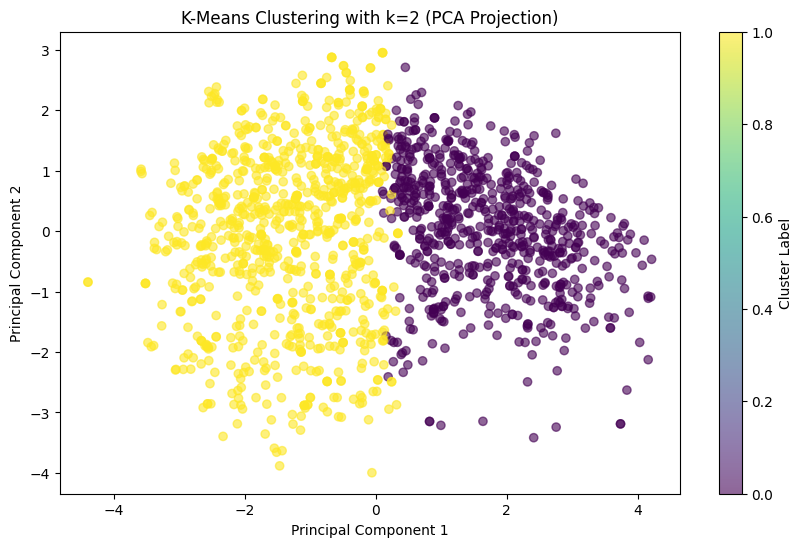

In [296]:
# Visualizing Clusters in PCA Space
plt.figure(figsize=(10, 6))
plt.scatter(pca_transformed_optimal[:, 0], pca_transformed_optimal[:, 1], c=df["cluster"], cmap='viridis', alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering with k=2 (PCA Projection)")
plt.colorbar(label="Cluster Label")
plt.show()

In [297]:
# Select features for visualization
features_to_plot = ["danceability", "energy", "instrumentalness", "speechiness", "tempo", "valence"]


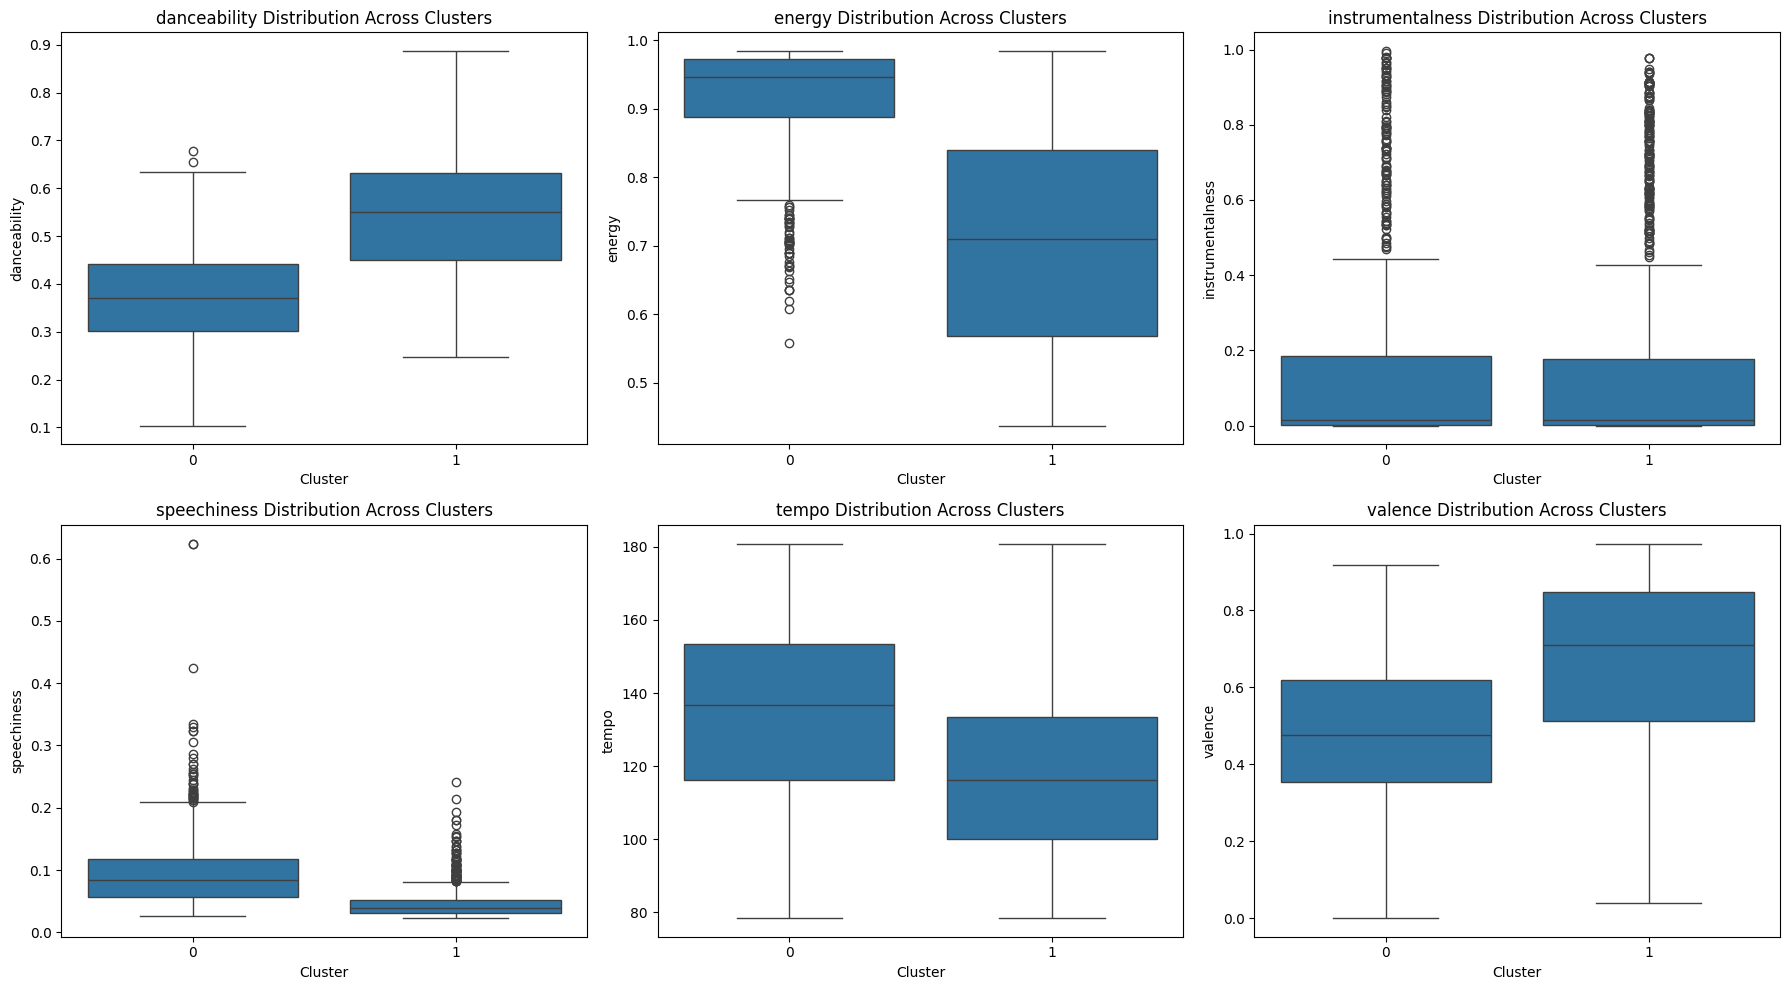

In [298]:
# Create subplots to visualize feature distributions across clusters
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, feature in enumerate(features_to_plot):
    row, col = divmod(i, 3)
    sns.boxplot(x=df["cluster"], y=df[feature], ax=axes[row, col])
    axes[row, col].set_title(f"{feature} Distribution Across Clusters")
    axes[row, col].set_xlabel("Cluster")
    axes[row, col].set_ylabel(feature)

plt.tight_layout()
plt.show()

**Cluster 0 (Energetic & High Speech Content)**

Low danceability (suggests complex beats or non-dance genres).

High energy (very concentrated near 1).

High speechiness (many outliers, possibly rap/spoken word).

High tempo (faster-paced songs).

Low valence (less "happy" or "positive" songs).

Likely represents high-energy, fast-tempo, spoken or rap-heavy music.

**Cluster 1 (Danceable & Positive Mood)**

Higher danceability (easier to dance to).

Wider range of energy levels (from low to high).

More balanced tempo (not too fast).

Lower speechiness (fewer spoken elements, more melodic).

Higher valence (happier or more uplifting songs).

Likely represents danceable, feel-good, and positive mood music.


### Hierarchical Clustering

In [299]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

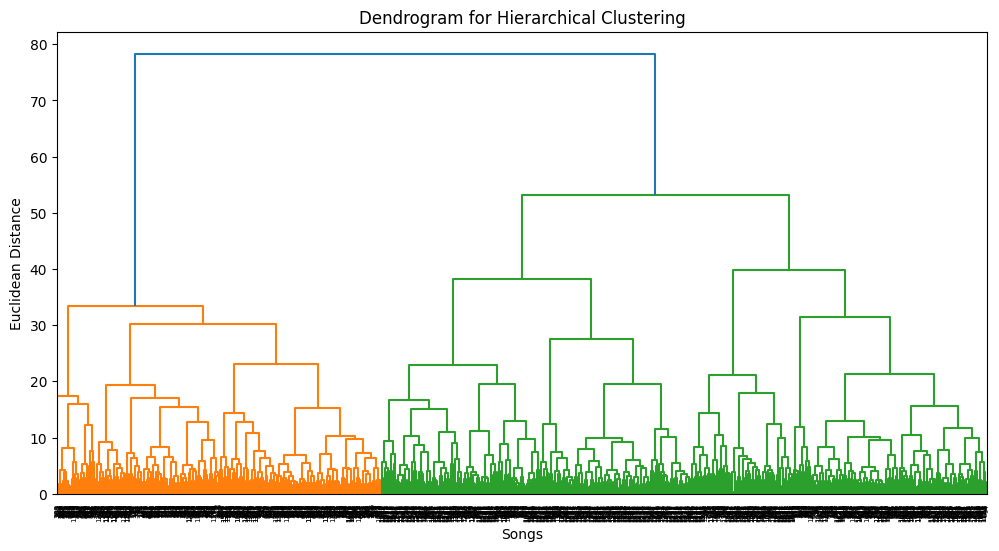

In [300]:
# Plot Dendrogram for Hierarchical Clustering
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(pca_transformed_optimal, method="ward"))
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Songs")
plt.ylabel("Euclidean Distance")
plt.show()

optimal no of cluster = 2 (The optimal number of clusters is found where we see the largest vertical jump before a merge happens.)

In [301]:
# Apply Agglomerative Clustering with k=2 (same as K-Means for comparison)
hierarchical_clustering = AgglomerativeClustering(n_clusters=2, linkage="ward")
df["hierarchical_cluster"] = hierarchical_clustering.fit_predict(pca_transformed_optimal)

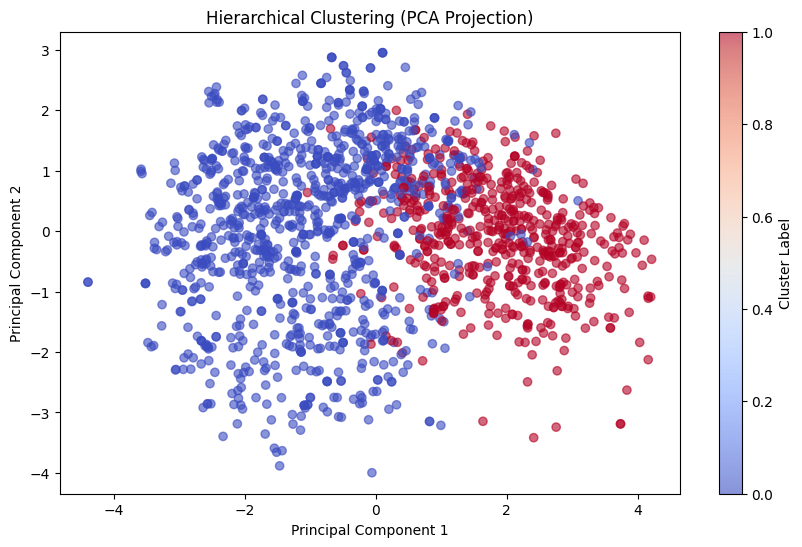

In [302]:
# Visualize hierarchical clusters in PCA space
plt.figure(figsize=(10, 6))
plt.scatter(pca_transformed_optimal[:, 0], pca_transformed_optimal[:, 1],
            c=df["hierarchical_cluster"], cmap="coolwarm", alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clustering (PCA Projection)")
plt.colorbar(label="Cluster Label")
plt.show()


## Identify the Right Number of Clusters

--> Using elbow method, elbow point is 2 , suggests two clusters best represnt the data.

--> The dendrogram also showed a major split at k=2, further confirming two strong clusters.

Final Decision: k=2 is the best choice, as all methods point to two well-separated clusters.

## Use Appropriate Clustering Algorithms

Tested Two Approaches:

1) K-Means Clustering:
2)  Hierarchical Clustering

Final Decision: K-Means is the best choice because it is scalable and effective while producing similar results as Hierarchical Clustering.

## Define Each Cluster Based on Features

Cluster Interpretations:

**Cluster 0 (Energetic & High Speech Content)**

Low danceability (suggests complex beats or non-dance genres).

High energy (very concentrated near 1).

High speechiness (many outliers, possibly rap/spoken word).

High tempo (faster-paced songs).

Low valence (less "happy" or "positive" songs).

Likely represents high-energy, fast-tempo, spoken or rap-heavy music.

**Cluster 1 (Danceable & Positive Mood)**

Higher danceability (easier to dance to).

Wider range of energy levels (from low to high).

More balanced tempo (not too fast).

Lower speechiness (fewer spoken elements, more melodic).

Higher valence (happier or more uplifting songs).

Likely represents danceable, feel-good, and positive mood music.

